In [1]:
import pyspedas
import pytplot
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.cm as cm
# %matplotlib tk

import scipy
from scipy import interpolate,optimize
from scipy.optimize import curve_fit
from skimage.transform import probabilistic_hough_line

import helper
from helper import UTC_to_UNX
from helper import UNX_to_UTC
from helper import find_closest_index_dt

import math
from scipy.interpolate import interp1d

In [2]:
from detection_helper import *

In [3]:
times_arr, freq_arr, data_arr = return_arr('2023-08-19', '2023-08-20')

25-Nov-25 02:22:10: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
25-Nov-25 02:22:10: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230819_v03.cdf
25-Nov-25 02:22:10: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
25-Nov-25 02:22:11: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230819_v03.cdf
25-Nov-25 02:22:11: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
25-Nov-25 02:22:11: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230819_v03.cdf
25-Nov-25 02:22:11: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
25-Nov-25 02:22:12: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230819_v03.cdf


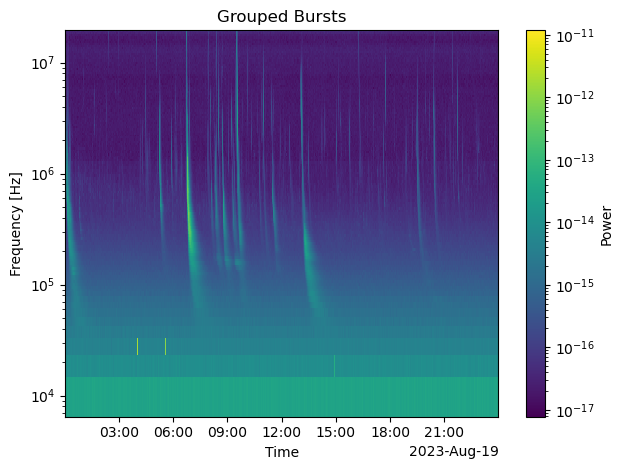

In [4]:
fig, ax = plt.subplots()
p = ax.pcolormesh(times_arr, freq_arr, data_arr.T, norm=LogNorm())
plt.colorbar(p, label='Power')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
freq_log, freq_log_exp, new_times_arr, data_arr_log = convert_data_log_square(freq_arr, times_arr, data_arr)

In [29]:
data_arr_log.shape

(1440, 1440)

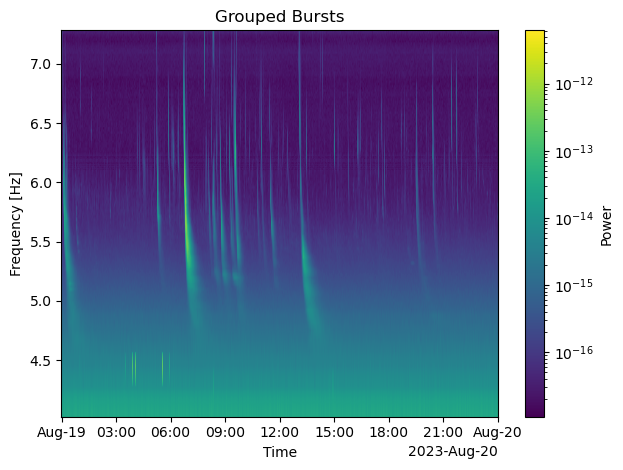

In [6]:
fig, ax = plt.subplots()
p = ax.pcolormesh(new_times_arr, freq_log_exp, data_arr_log.T, norm=LogNorm())
plt.colorbar(p, label='Power')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

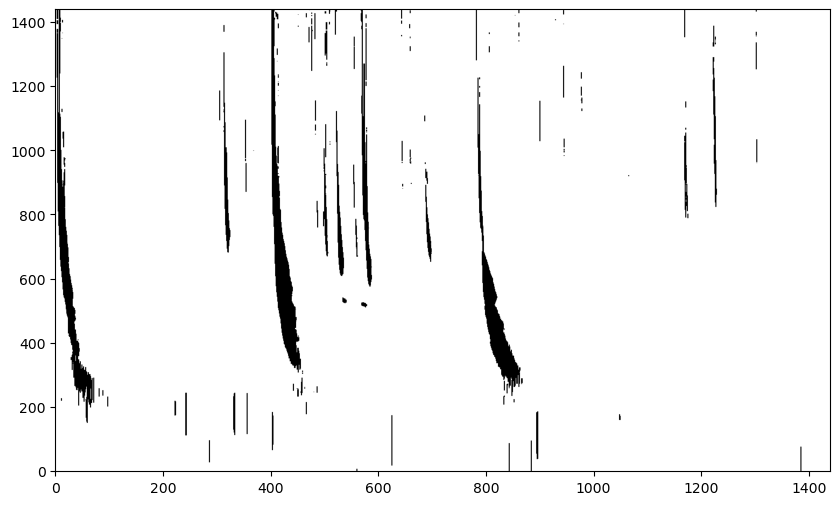

In [7]:
bmap_row_mean = bmap_row_mean_loop_new(times_arr=times_arr, full_data=data_arr_log, min_duration=1)

plt.figure(figsize=(10, 6))
plt.imshow(1-bmap_row_mean.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

In [31]:
bmap_row_mean.shape

(1440, 1440)

In [119]:
data_arr_log.shape

(1440, 1440)

In [133]:
lines = hough_detect(bmap_row_mean, data_arr_log, threshold=10, line_gap=50, line_length=100, theta=np.deg2rad(np.linspace(80, 90, 120)))
lines

[((334, 438), (1189, 402)),
 ((394, 426), (1361, 402)),
 ((806, 419), (1146, 402)),
 ((321, 445), (862, 416)),
 ((406, 424), (1257, 402)),
 ((1253, 571), (1438, 568)),
 ((579, 583), (1153, 573)),
 ((321, 444), (814, 418)),
 ((244, 46), (1064, 4)),
 ((604, 12), (1117, 6)),
 ((519, 19), (1202, 7)),
 ((491, 416), (1438, 404)),
 ((253, 39), (1145, 4)),
 ((334, 439), (790, 419)),
 ((1119, 575), (1269, 573)),
 ((329, 442), (893, 403)),
 ((528, 413), (1030, 407)),
 ((247, 46), (982, 4)),
 ((798, 572), (1105, 572)),
 ((1059, 408), (1321, 402)),
 ((859, 571), (1252, 571)),
 ((249, 47), (945, 4)),
 ((501, 415), (954, 409)),
 ((243, 459), (687, 428)),
 ((518, 31), (694, 22)),
 ((1081, 409), (1438, 402)),
 ((521, 19), (890, 13)),
 ((307, 451), (650, 433)),
 ((265, 37), (628, 23)),
 ((890, 18), (1056, 14)),
 ((244, 47), (747, 7)),
 ((1290, 406), (1438, 405)),
 ((785, 573), (969, 573)),
 ((795, 405), (1218, 404)),
 ((663, 25), (994, 4)),
 ((1045, 10), (1262, 3)),
 ((396, 425), (1007, 413)),
 ((599, 

In [121]:
len(new_times_arr)

1440

In [135]:
line_sets, line_sets_actual = line_grouping_new(new_times_arr, freq_log, lines, time_diff=1, freq_diff=1)
line_sets_actual

[(('2023-08-19 00:03:06.925285+00:00', 7616132.514335706),
  ('2023-08-19 00:10:07.163074+00:00', 2455831.0943104452)),
 (('2023-08-19 00:03:06.925285+00:00', 17545160.581572335),
  ('2023-08-19 00:05:06.993225+00:00', 7229080.540468166)),
 (('2023-08-19 00:03:06.925285+00:00', 6411871.023617714),
  ('2023-08-19 00:09:07.129104+00:00', 2155608.674801981)),
 (('2023-08-19 00:03:06.925285+00:00', 12115245.116786651),
  ('2023-08-19 00:07:07.061165+00:00', 1695795.0048201282)),
 (('2023-08-19 00:03:06.925285+00:00', 8193066.722502615),
  ('2023-08-19 00:07:07.061165+00:00', 1348053.307673861)),
 (('2023-08-19 00:03:06.925285+00:00', 19072149.08906647),
  ('2023-08-19 00:05:06.993225+00:00', 9731867.909932911)),
 (('2023-08-19 00:03:06.925285+00:00', 12965195.274954969),
  ('2023-08-19 00:05:06.993225+00:00', 5776728.024135957)),
 (('2023-08-19 00:04:06.959255+00:00', 2711666.0760128545),
  ('2023-08-19 00:46:08.385987+00:00', 37654.68967887087)),
 (('2023-08-19 00:04:06.959255+00:00', 413

<Figure size 1000x600 with 0 Axes>

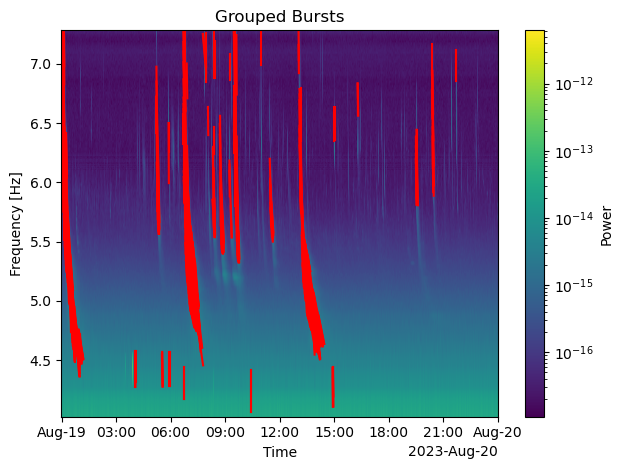

In [137]:
plt.figure(figsize=(10, 6))

fig, ax = plt.subplots()
p = ax.pcolormesh(new_times_arr, freq_log_exp, data_arr_log.T, norm=LogNorm())
plt.colorbar(p, label='Power')

for (x0, y0), (x1, y1) in line_sets:
    t0, t1 = new_times_arr[y0], new_times_arr[y1]
    f0, f1 = freq_log_exp[x0], freq_log_exp[x1]
    # print(t0, t1, f0, f1)
    ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

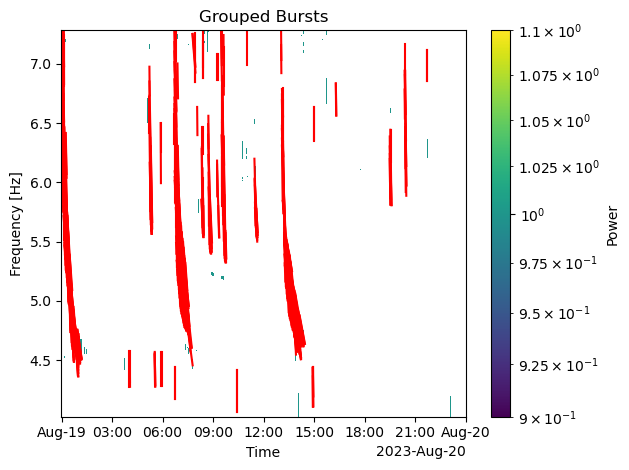

In [139]:
plt.figure(figsize=(10, 6))

fig, ax = plt.subplots()
p = ax.pcolormesh(new_times_arr, freq_log_exp, bmap_row_mean.T, norm=LogNorm())
plt.colorbar(p, label='Power')

for (x0, y0), (x1, y1) in line_sets:
    t0, t1 = new_times_arr[y0], new_times_arr[y1]
    f0, f1 = freq_log_exp[x0], freq_log_exp[x1]
    # print(t0, t1, f0, f1)
    ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()